This part is the same as the from-scratch CNN, except this time we try to dilate the convolutions. Thus, the code is really similar to the from-scratch one.

# Extract data + Spectrogram generation



This is exactly the same process as in the others CNN.

In [2]:
import audb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader

# Load the emodb database
db = audb.load("emodb")

Get:   emodb v2.0.0
Cache: /home/nathan/audb/emodb/2.0.0/d3b62a9b


In [3]:
train_data: pd.DataFrame = db["emotion.categories.train.gold_standard"].get().copy()
test_data: pd.DataFrame = db["emotion.categories.test.gold_standard"].get().copy()

In [4]:
def truncate_or_pad(x, target_len):
    current_len = x.shape[1]

    if isinstance(x, torch.Tensor):
        if current_len > target_len:
            return x[:, :target_len]
        else:
            pad_size = target_len - current_len
            pad_shape = (1, pad_size)
            padding = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
            return torch.cat([x, padding], dim=1)


def compute_spectrogram(file_path):
    waveform, sample_rate = torchaudio.load(file_path)
    waveform = truncate_or_pad(waveform, sample_rate * 3)

    # 25ms windows every 10ms
    window_length = int(sample_rate * 0.025)  # 25ms frames
    hop_length = int(sample_rate * 0.010)  # 10ms hop

    mel_transform = T.MelSpectrogram(
        sample_rate=sample_rate,
        win_length=window_length,
        hop_length=hop_length,
        n_mels=64,
    )

    amp_to_db = T.AmplitudeToDB(stype="power", top_db=80)

    spec_db = amp_to_db(mel_transform(waveform)).squeeze(0)

    return spec_db


def add_spectrogram_col(datafram_data):
    spectrogram_list = []
    for file_path in datafram_data.index:
        spectrogram_list.append(compute_spectrogram(file_path))

    datafram_data.insert(1, "spectrogram", spectrogram_list)

add_spectrogram_col(train_data)
add_spectrogram_col(test_data)

In [5]:
print("Number of training audios: ", len(train_data))
print("Number of testing audios:  ", len(test_data))


Number of training audios:  304
Number of testing audios:   231


# Dilated from-scratch CNN
## 1. Architecture definition
This architecture is the same as the "normal" from-scratch CNN, except the convolutions are dilated.

In [6]:
class fromScratchDilated(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=256,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=2,
                dilation=2,
                bias=False
            ),
            nn.BatchNorm2d(num_features=256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.5)
        self.fc = nn.Linear(in_features=256, out_features=7)


    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

## 2. Dataset and dataloader definition, Training preparation, Training

In [7]:
classes = sorted(train_data['emotion'].unique())
label2id = {emotion: i for i, emotion in enumerate(classes)}

# Dataset definition
class EmotionDataset(Dataset):
    def __init__(self, df, label_mapping):
        self.spectrograms = df['spectrogram'].values
        self.labels = [label_mapping[emo] for emo in df['emotion']]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        spec = self.spectrograms[idx].unsqueeze(0).float()
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return spec, label

# Dataloaders definition
train_dataset = EmotionDataset(train_data, label2id)
test_dataset = EmotionDataset(test_data, label2id)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on : {device}")

model = fromScratchDilated(in_channels=1).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

Training on : cpu


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for specs, labels in loader:
        specs, labels = specs.to(device), labels.to(device)

        # steps to train the model on current batch
        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * specs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for specs, labels in loader:
            specs, labels = specs.to(device), labels.to(device)
            outputs = model(specs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * specs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [10]:
EPOCHS = 50
best_test_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "fromScratchDilated_trained.pth")

    print(f"Epoch [{epoch:02d}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.1f}% | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc*100:.1f}%")

print(f"\nBest precision on test set : {best_test_acc*100:.2f}%.")

Epoch [01/50] | Train Loss: 1.6762, Acc: 35.9% | Test Loss: 2.3244, Acc: 16.5%
Epoch [02/50] | Train Loss: 1.2468, Acc: 51.0% | Test Loss: 3.1691, Acc: 19.9%
Epoch [03/50] | Train Loss: 1.0421, Acc: 59.2% | Test Loss: 1.5887, Acc: 38.1%
Epoch [04/50] | Train Loss: 0.8293, Acc: 69.1% | Test Loss: 1.2535, Acc: 52.4%
Epoch [05/50] | Train Loss: 0.7393, Acc: 74.7% | Test Loss: 9.5374, Acc: 16.5%
Epoch [06/50] | Train Loss: 0.5769, Acc: 80.9% | Test Loss: 2.2336, Acc: 46.3%
Epoch [07/50] | Train Loss: 0.5489, Acc: 81.6% | Test Loss: 4.9610, Acc: 27.7%
Epoch [08/50] | Train Loss: 0.5925, Acc: 76.6% | Test Loss: 2.4575, Acc: 50.2%
Epoch [09/50] | Train Loss: 0.3712, Acc: 90.8% | Test Loss: 1.1630, Acc: 58.4%
Epoch [10/50] | Train Loss: 0.3798, Acc: 88.5% | Test Loss: 2.2241, Acc: 48.5%
Epoch [11/50] | Train Loss: 0.4127, Acc: 86.8% | Test Loss: 4.2247, Acc: 23.8%
Epoch [12/50] | Train Loss: 0.3089, Acc: 92.1% | Test Loss: 1.6057, Acc: 60.2%
Epoch [13/50] | Train Loss: 0.2310, Acc: 95.4% | Tes

## 3. Evaluation

In [15]:
# Get the prediction results on the entire database
import numpy as np
from sklearn.metrics import recall_score

model.load_state_dict(torch.load("fromScratchDilated_trained.pth"))

# The evalution process is the same as the  evaluation process in training phase

def evaluate_model(loader, dataset_name):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():  # We are not training !
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_samples += labels.size(0)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / total_samples
    accuracy = (all_preds == all_labels).mean()
    # unweighted recall is equivalent to macro recall
    uar = recall_score(all_labels, all_preds, average="macro")

    print(f"=== {dataset_name} Evaluation ===")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.2%}")
    print(f"UAR (Macro Recall): {uar:.2%}\n")

    return all_labels, all_preds


y_test, test_preds = evaluate_model(test_loader, "Test Dataset")

=== Test Dataset Evaluation ===
Loss: 0.9038
Accuracy: 76.62%
UAR (Macro Recall): 73.72%



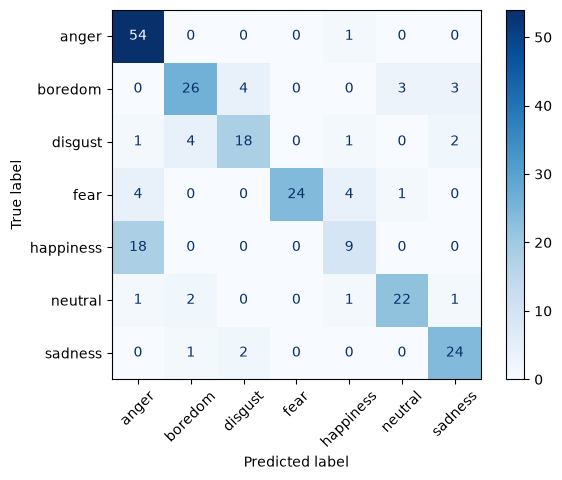

In [18]:
# Create confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the classes
classes = list(label2id.keys())

# Test Confusion Matrix
cm_test = confusion_matrix(y_test, test_preds)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=classes)
disp_test.plot(cmap="Blues", xticks_rotation=45)
plt.show()